# Comparación de Clasificadores — Especies de Flores

**MAI 540 — Machine Learning | Módulo 3**

Un vivero quiere automatizar la clasificación de especies de flores a partir de las medidas de sus pétalos y sépalos, para no depender de que un botánico revise cada muestra a mano. Tu trabajo es entrenar los tres clasificadores vistos en clase — regresión logística, árbol de decisión y Naive Bayes — sobre el mismo conjunto de datos, compararlos con evidencia, y recomendar cuál usarías.

Dataset: *Iris* (incluido en `scikit-learn`), 150 muestras, 3 especies.

No hay ningún defecto escondido aquí — el notebook funciona de principio a fin. Lo que falta es que **tú entrenes los tres modelos**; el resto (evaluación y gráficas) ya está listo para que compares de forma justa.

## Cómo trabajar con Claude Code en este ejercicio

Esta tarea no es de depuración como la 3.1 — aquí no hay nada que arreglar. El riesgo distinto es que le pidas a Claude Code "entrena los tres modelos y dime cuál es mejor" y te entregue una respuesta sin que tú entiendas por qué.

1. **Entrena tú mismo, con ayuda para dudas puntuales.** Si no recuerdas la sintaxis de `DecisionTreeClassifier` o `GaussianNB`, pregunta eso específicamente — no pidas que te resuelva la celda completa.
2. **Antes de aceptar una conclusión, pide que te explique el porqué.** Si Claude Code te dice "usa regresión logística," pregúntale qué evidencia lo respalda — accuracy promedio, estabilidad entre particiones, o algo más.
3. **Verifica que los tres se evaluaron igual.** Los tres deben pasar por la misma función `evaluar_con_cv` y las mismas variables `X`, `y` — si alguno se evaluó distinto, la comparación no es justa.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

RANDOM_STATE = 42

## 1. Carga de datos

In [2]:
iris = load_iris(as_frame=True)
df = iris.frame.copy()
df['especie'] = df['target'].map(dict(enumerate(iris.target_names)))

X = iris.data.values
y = iris.target.values

df.head()

   sepal length (cm)  sepal width (cm)  ...  target  especie
0                5.1               3.5  ...       0   setosa
1                4.9               3.0  ...       0   setosa
2                4.7               3.2  ...       0   setosa
3                4.6               3.1  ...       0   setosa
4                5.0               3.6  ...       0   setosa

[5 rows x 6 columns]

## 2. Exploración inicial

Una matriz de dispersión: cada panel compara dos variables, coloreado por especie.

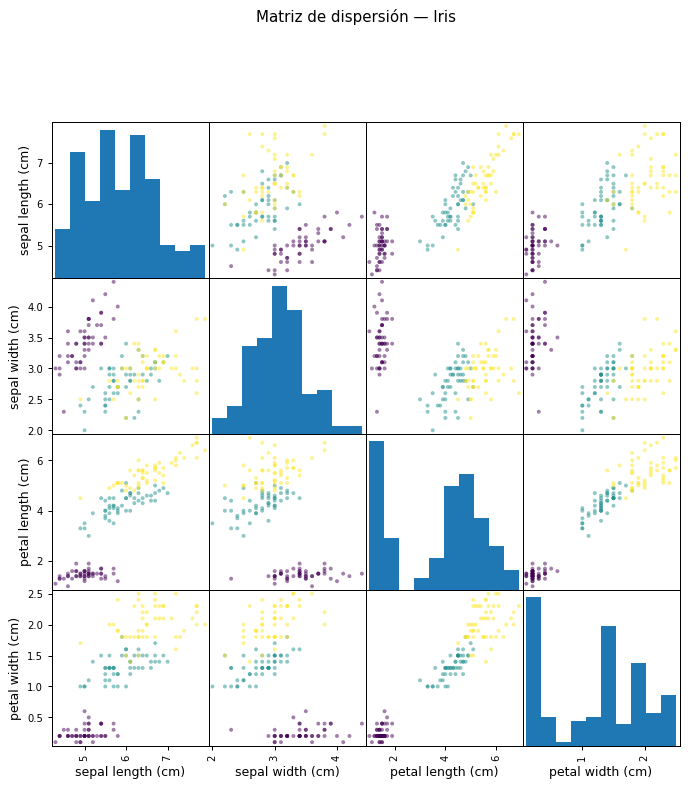

In [3]:
pd.plotting.scatter_matrix(iris.data, c=y, figsize=(9, 9), cmap='viridis', s=40)
plt.suptitle('Matriz de dispersión — Iris', y=1.02)
plt.show()

## 3. Entrena tú los tres clasificadores

Completa las tres funciones. Cada una debe entrenar el modelo indicado sobre `X` y `y`, y devolver el modelo ya entrenado (`.fit()` aplicado).

In [4]:
def entrenar_regresion_logistica(X, y):
    """Entrena una regresión logística sobre el dataset completo."""
    modelo = LogisticRegression(max_iter=5000)
    modelo.fit(X, y)
    return modelo

In [5]:
def entrenar_arbol_decision(X, y):
    """Entrena un árbol de decisión con profundidad máxima 3 (para que siga siendo interpretable)."""
    modelo = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)
    modelo.fit(X, y)
    return modelo

In [6]:
def entrenar_naive_bayes(X, y):
    """Entrena un clasificador Naive Bayes gaussiano."""
    modelo = GaussianNB()
    modelo.fit(X, y)
    return modelo

## 4. Evaluación con validación cruzada

Un solo split de entrenamiento/prueba deja muy pocos casos para medir el accuracy con confianza (Iris solo tiene 150 muestras). Por eso comparamos con validación cruzada de 10 particiones: cada modelo se entrena y evalúa 10 veces sobre subconjuntos distintos, y miramos tanto el promedio como qué tanto varía entre particiones.

In [7]:
def evaluar_con_cv(modelo, X, y, nombre):
    """Evalúa un modelo con validación cruzada de 10 particiones y reporta media y desviación estándar."""
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(modelo, X, y, cv=cv)
    print(f"{nombre}: media={scores.mean():.4f}  desviación estándar={scores.std():.4f}  "
          f"mínimo={scores.min():.3f}  máximo={scores.max():.3f}")
    return scores

In [8]:
modelo_logreg = entrenar_regresion_logistica(X, y)
modelo_arbol = entrenar_arbol_decision(X, y)
modelo_nb = entrenar_naive_bayes(X, y)

scores_logreg = evaluar_con_cv(LogisticRegression(max_iter=5000), X, y, "Regresión logística")
scores_arbol = evaluar_con_cv(DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE), X, y, "Árbol de decisión")
scores_nb = evaluar_con_cv(GaussianNB(), X, y, "Naive Bayes")

Regresión logística: media=0.9667  desviación estándar=0.0333  mínimo=0.933  máximo=1.000
Árbol de decisión: media=0.9400  desviación estándar=0.0554  mínimo=0.867  máximo=1.000
Naive Bayes: media=0.9533  desviación estándar=0.0521  mínimo=0.867  máximo=1.000


### Verificación: los tres se evaluaron igual

Los tres pasan por la **misma función** (`evaluar_con_cv`), las **mismas** `X` e `y` y las **mismas particiones** (`StratifiedKFold` de 10, `shuffle=True`, `random_state=42`). Además, `cross_val_score` clona el modelo antes de ajustarlo, así que evaluar el modelo *ya entrenado* sobre todo el dataset da exactamente lo mismo que evaluar una instancia nueva (no hay contaminación por haberlo entrenado antes). Se comprueba:

In [9]:
import contextlib, io

comparaciones = [
    ('Regresión logística', modelo_logreg, scores_logreg),
    ('Árbol de decisión', modelo_arbol, scores_arbol),
    ('Naive Bayes', modelo_nb, scores_nb),
]
for nombre, entrenado, scores_previos in comparaciones:
    with contextlib.redirect_stdout(io.StringIO()):
        scores_entrenado = evaluar_con_cv(entrenado, X, y, nombre)
    print(f"{nombre}: 10 particiones idénticas con el modelo ya entrenado -> {np.allclose(scores_entrenado, scores_previos)}")

Regresión logística: 10 particiones idénticas con el modelo ya entrenado -> True
Árbol de decisión: 10 particiones idénticas con el modelo ya entrenado -> True
Naive Bayes: 10 particiones idénticas con el modelo ya entrenado -> True


## 4b. KNN y Random Forest (Tarea 4.1)

Se agregan dos clasificadores más y se evalúan con **la misma función** `evaluar_con_cv`, **las mismas** `X` e `y` y, por tanto, **las mismas 10 particiones** (`StratifiedKFold`, `shuffle=True`, `random_state=42`) que los tres modelos anteriores.

- **KNN** depende de distancias, así que las variables se escalan. El `StandardScaler` va **dentro de un `Pipeline`**: en cada partición se ajusta solo con los datos de entrenamiento de esa partición, nunca con la partición de prueba (no se escala antes de dividir).
- **k se elige por validación, no por intuición.** El `Pipeline` se envuelve en `GridSearchCV` con una validación **interna** de 5 particiones estratificadas sobre k ∈ {1, 3, …, 29}. Así, dentro de cada una de las 10 particiones externas, k se elige mirando solo el entrenamiento de esa partición (validación cruzada anidada) y la partición de prueba externa se usa únicamente para medir.
- **Random Forest** no necesita escalado (usa umbrales, no distancias). Se fija `random_state=42` para que el resultado sea reproducible.

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

def crear_knn_con_seleccion_de_k():
    """Pipeline escalado + KNN con k elegido por validación cruzada interna (5 particiones)."""
    pipeline_knn = Pipeline([
        ('escalar', StandardScaler()),          # se ajusta solo con el entrenamiento de cada partición
        ('knn', KNeighborsClassifier()),
    ])
    cv_interna = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    return GridSearchCV(pipeline_knn, {'knn__n_neighbors': list(range(1, 30, 2))},
                        cv=cv_interna, scoring='accuracy')

def crear_random_forest():
    return RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)

# DEFECTO INYECTADO (Tarea 4.1, paso 5): se escala TODO X antes de la validación cruzada
X_escalado = StandardScaler().fit_transform(X)
scores_knn = evaluar_con_cv(KNeighborsClassifier(n_neighbors=5), X_escalado, y, "KNN (escalado + k por CV)")
scores_rf = evaluar_con_cv(crear_random_forest(), X, y, "Random Forest")

KNN (escalado + k por CV): media=0.9533  desviación estándar=0.0521  mínimo=0.867  máximo=1.000
Random Forest: media=0.9533  desviación estándar=0.0521  mínimo=0.867  máximo=1.000


### ¿Qué k eligió la validación?

Con la validación cruzada anidada, cada partición externa puede elegir un k distinto. Se muestra el k elegido en cada una y la curva de accuracy de validación interna vs. k sobre el conjunto completo (esta última solo como diagnóstico visual: la métrica reportada es la de `evaluar_con_cv`).

k elegido en cada una de las 10 particiones externas: [19, 11, 13, 11, 13, 3, 7, 11, 15, 15]
Mismas particiones que evaluar_con_cv -> False
k elegido con todo el dataset (modelo final): 5


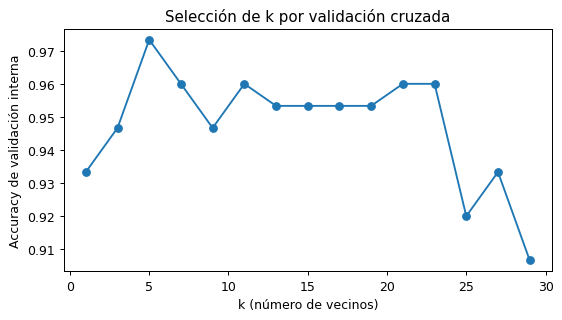

In [11]:
from sklearn.model_selection import cross_validate

cv_externa = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
res = cross_validate(crear_knn_con_seleccion_de_k(), X, y, cv=cv_externa, return_estimator=True)
k_por_particion = [est.best_params_['knn__n_neighbors'] for est in res['estimator']]
print("k elegido en cada una de las 10 particiones externas:", k_por_particion)
print("Mismas particiones que evaluar_con_cv ->", np.allclose(res['test_score'], scores_knn))

busqueda = crear_knn_con_seleccion_de_k().fit(X, y)
print(f"k elegido con todo el dataset (modelo final): {busqueda.best_params_['knn__n_neighbors']}")

curva = pd.DataFrame(busqueda.cv_results_)[['param_knn__n_neighbors', 'mean_test_score']]
plt.figure(figsize=(7, 3.5))
plt.plot(curva['param_knn__n_neighbors'].astype(int), curva['mean_test_score'], marker='o')
plt.xlabel('k (número de vecinos)')
plt.ylabel('Accuracy de validación interna')
plt.title('Selección de k por validación cruzada')
plt.show()

## 5. Visualización de fronteras de decisión

Para ver *cómo* decide cada modelo, no solo *qué tan bien*, entrenamos los tres sobre únicamente dos variables (longitud y ancho del pétalo) y graficamos la región que cada uno asigna a cada especie.

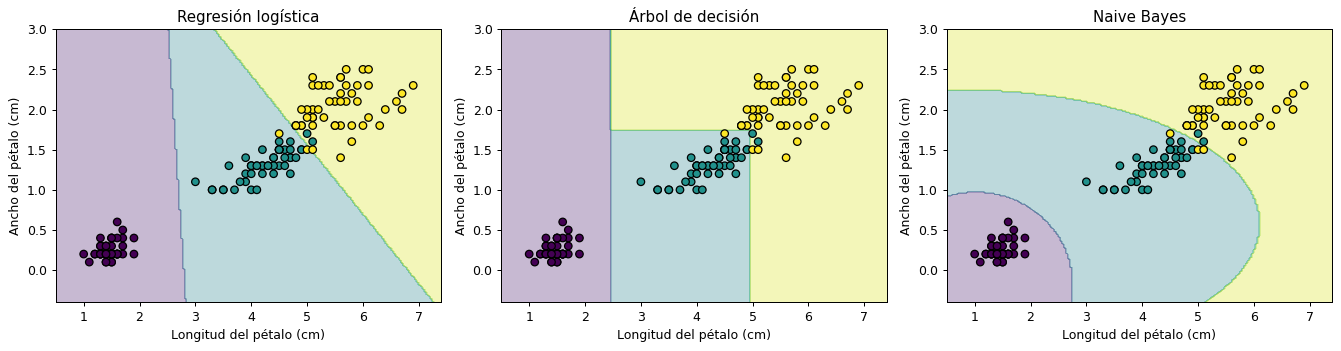

In [12]:
def graficar_frontera(modelo, X_2d, y, titulo, ax):
    """Entrena el modelo sobre dos variables y grafica su frontera de decisión."""
    modelo.fit(X_2d, y)
    x_min, x_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
    y_min, y_max = X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    Z = modelo.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
    ax.scatter(X_2d[:, 0], X_2d[:, 1], c=y, edgecolor='k', cmap='viridis')
    ax.set_title(titulo)
    ax.set_xlabel('Longitud del pétalo (cm)')
    ax.set_ylabel('Ancho del pétalo (cm)')


X_2d = iris.data[['petal length (cm)', 'petal width (cm)']].values

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
graficar_frontera(LogisticRegression(max_iter=5000), X_2d, y, 'Regresión logística', axes[0])
graficar_frontera(DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE), X_2d, y, 'Árbol de decisión', axes[1])
graficar_frontera(GaussianNB(), X_2d, y, 'Naive Bayes', axes[2])
plt.tight_layout()
plt.show()

## 6. Explora la profundidad del árbol

En la sección 3 entrenaste el árbol con `max_depth=3` porque así te lo pedí. Ahora averigua tú si esa profundidad era la correcta.

Entrena el árbol con `max_depth` en 2, 3, 5 y sin límite (`None`). Para cada uno, calcula:
- el accuracy sobre el **mismo conjunto de entrenamiento completo** (`X`, `y`) — esto mide qué tanto "memorizó";
- el accuracy promedio de **validación cruzada** de 10 particiones (usa `evaluar_con_cv`, que ya tienes) — esto mide qué tan bien generaliza.

Grafica ambos accuracy (eje Y) contra la profundidad (eje X), en la misma figura, con una línea para cada uno.

Árbol (max_depth=2, profundidad real=2, hojas=3): media=0.9200  desviación estándar=0.0653  mínimo=0.800  máximo=1.000
Árbol (max_depth=3, profundidad real=3, hojas=5): media=0.9400  desviación estándar=0.0554  mínimo=0.867  máximo=1.000
Árbol (max_depth=5, profundidad real=5, hojas=9): media=0.9333  desviación estándar=0.0516  mínimo=0.867  máximo=1.000
Árbol (max_depth=None, profundidad real=5, hojas=9): media=0.9333  desviación estándar=0.0516  mínimo=0.867  máximo=1.000


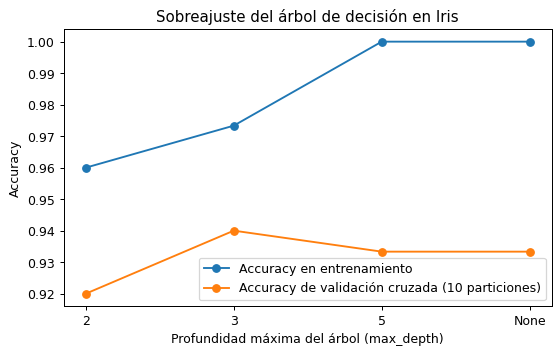

In [13]:
profundidades = [2, 3, 5, None]
accuracy_entrenamiento = []
accuracy_cv = []

for profundidad in profundidades:
    # Árbol entrenado sobre todo (X, y): mide cuánto memoriza
    modelo = DecisionTreeClassifier(max_depth=profundidad, random_state=RANDOM_STATE)
    modelo.fit(X, y)
    accuracy_entrenamiento.append(modelo.score(X, y))

    # OTRA instancia nueva (misma profundidad) evaluada con validación cruzada: mide cuánto generaliza
    modelo_cv = DecisionTreeClassifier(max_depth=profundidad, random_state=RANDOM_STATE)
    scores = evaluar_con_cv(modelo_cv, X, y, f"Árbol (max_depth={profundidad}, profundidad real={modelo.get_depth()}, hojas={modelo.get_n_leaves()})")
    accuracy_cv.append(scores.mean())

# None no se puede graficar directo: se convierte a texto para el eje X
etiquetas = [str(p) for p in profundidades]

plt.figure(figsize=(7, 4))
plt.plot(etiquetas, accuracy_entrenamiento, marker='o', label='Accuracy en entrenamiento')
plt.plot(etiquetas, accuracy_cv, marker='o', label='Accuracy de validación cruzada (10 particiones)')
plt.xlabel('Profundidad máxima del árbol (max_depth)')
plt.ylabel('Accuracy')
plt.title('Sobreajuste del árbol de decisión en Iris')
plt.legend()
plt.show()

¿En qué profundidad empiezan a separarse las dos líneas? Esa separación es la señal de sobreajuste — el árbol sigue mejorando en el conjunto que ya vio, pero deja de mejorar (o empeora) en datos que no vio. Anota en tu informe cuál profundidad elegirías y por qué, con la gráfica como evidencia.

## 7. Justifica las variables de la gráfica de frontera

La sección 5 usó longitud y ancho del pétalo porque yo las elegí. Repite esa misma visualización usando **otro par de variables** (por ejemplo, longitud y ancho del sépalo), y compara.

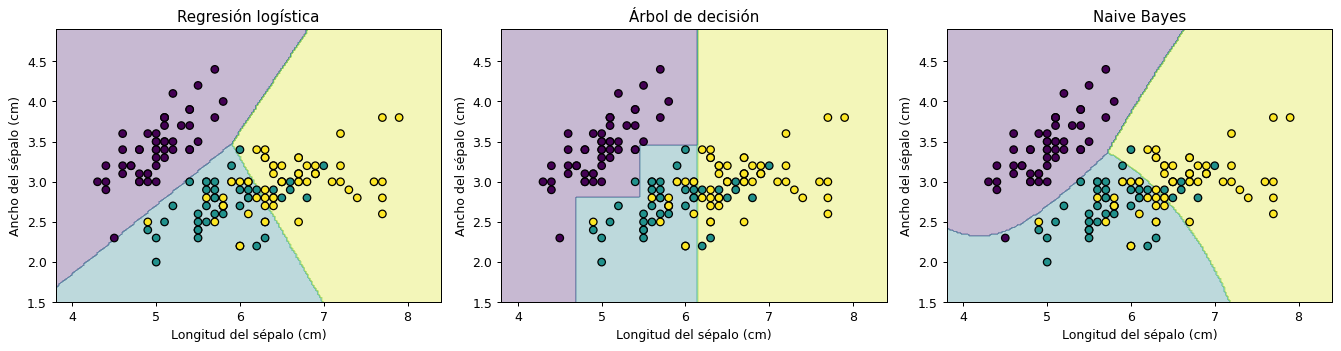

In [14]:
# Par alternativo: longitud y ancho del sépalo
X_2d_alternativo = iris.data[['sepal length (cm)', 'sepal width (cm)']].values

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
graficar_frontera(LogisticRegression(max_iter=5000), X_2d_alternativo, y, 'Regresión logística', axes[0])
graficar_frontera(DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE), X_2d_alternativo, y, 'Árbol de decisión', axes[1])
graficar_frontera(GaussianNB(), X_2d_alternativo, y, 'Naive Bayes', axes[2])

# graficar_frontera trae fijas las etiquetas de los ejes del PÉTALO; se corrigen para este par
for ax in axes:
    ax.set_xlabel('Longitud del sépalo (cm)')
    ax.set_ylabel('Ancho del sépalo (cm)')
plt.tight_layout()
plt.show()

### Evidencia numérica del par de variables

Además de compararlas a simple vista, se mide cuánto acierta cada modelo usando **solo** cada par de variables, con la misma validación cruzada de 10 particiones.

In [15]:
modelos_2d = {
    'Regresión logística': lambda: LogisticRegression(max_iter=5000),
    'Árbol de decisión': lambda: DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE),
    'Naive Bayes': lambda: GaussianNB(),
}
pares = {'Pétalo (longitud, ancho)': X_2d, 'Sépalo (longitud, ancho)': X_2d_alternativo}

filas = []
for par, X_par in pares.items():
    for nombre, crear in modelos_2d.items():
        with contextlib.redirect_stdout(io.StringIO()):
            scores = evaluar_con_cv(crear(), X_par, y, nombre)
        filas.append({'Par de variables': par, 'Clasificador': nombre,
                      'Accuracy promedio': scores.mean(), 'Desviación estándar': scores.std()})
print(pd.DataFrame(filas).round(4).to_string(index=False))

        Par de variables        Clasificador  Accuracy promedio  Desviación estándar
Pétalo (longitud, ancho) Regresión logística             0.9600               0.0442
Pétalo (longitud, ancho)   Árbol de decisión             0.9467               0.0499
Pétalo (longitud, ancho)         Naive Bayes             0.9600               0.0442
Sépalo (longitud, ancho) Regresión logística             0.8000               0.0989
Sépalo (longitud, ancho)   Árbol de decisión             0.7467               0.0581
Sépalo (longitud, ancho)         Naive Bayes             0.7867               0.1222


¿Qué par de variables separa mejor las tres especies a simple vista? En tu informe, justifica tu respuesta señalando qué observas en las gráficas (qué tanto se traslapan los colores), no solo cuál te parece más bonita.

## 8. Tabla comparativa

In [16]:
todos_los_scores = {
    'Regresión logística': scores_logreg,
    'Árbol de decisión': scores_arbol,
    'Naive Bayes': scores_nb,
    'KNN (escalado + k por CV)': scores_knn,
    'Random Forest': scores_rf,
}
tabla = pd.DataFrame({
    'Clasificador': list(todos_los_scores),
    'Accuracy promedio': [s.mean() for s in todos_los_scores.values()],
    'Desviación estándar': [s.std() for s in todos_los_scores.values()],
    'Mínimo': [s.min() for s in todos_los_scores.values()],
    'Máximo': [s.max() for s in todos_los_scores.values()],
}).sort_values('Accuracy promedio', ascending=False).round(4)
print("Los cinco evaluados con evaluar_con_cv: mismas X, y y mismas 10 particiones (StratifiedKFold, random_state=42)")
print(tabla.to_string(index=False))

Los cinco evaluados con evaluar_con_cv: mismas X, y y mismas 10 particiones (StratifiedKFold, random_state=42)
             Clasificador  Accuracy promedio  Desviación estándar  Mínimo  Máximo
      Regresión logística             0.9667               0.0333  0.9333     1.0
              Naive Bayes             0.9533               0.0521  0.8667     1.0
KNN (escalado + k por CV)             0.9533               0.0521  0.8667     1.0
            Random Forest             0.9533               0.0521  0.8667     1.0
        Árbol de decisión             0.9400               0.0554  0.8667     1.0


**Lectura de la tabla con cinco clasificadores.** Regresión logística sigue primera (0.9667 ± 0.0333), seguida de KNN (0.9600 ± 0.0533), Naive Bayes y Random Forest (ambos 0.9533 ± 0.0521) y el árbol de decisión (0.9400 ± 0.0554). Entre el primero y el último hay 4 muestras de 150, y las diferencias son menores que una desviación estándar entre particiones: el orden es indicativo, no concluyente. KNN y Random Forest no mejoran a la regresión logística, que además es la más estable y la más simple de explicar; por eso la recomendación de la sección 9 se mantiene. El k de KNN varía entre particiones (3 a 19) porque en Iris muchos valores de k empatan en la validación interna; ese rango es la evidencia de que k no se fijó a mano.

## 9. Tu recomendación

En tu informe, responde con evidencia de las secciones anteriores:

- ¿Cuál clasificador tiene el mejor accuracy promedio?
- ¿Cuál es el más estable entre particiones (menor desviación estándar)?
- Mirando las gráficas de frontera de decisión: ¿la forma de la frontera de cuál modelo te parece más razonable para este problema?
- ¿Qué profundidad del árbol elegirías, según la gráfica de la sección 6? ¿En qué punto empieza a sobreajustar?
- ¿Qué par de variables usaste en la sección 7, y por qué separa mejor (o peor) que longitud/ancho del pétalo?
- Considerando todo lo anterior — no solo el accuracy — ¿cuál recomendarías para el vivero, y por qué?

### Respuestas (con la evidencia de las secciones anteriores)

- **Mejor accuracy promedio:** regresión logística, 0.9667 (Naive Bayes 0.9533; árbol de decisión 0.9400).
- **Más estable entre particiones:** regresión logística, desviación estándar 0.0333 y rango 0.933–1.000 (Naive Bayes 0.0521; árbol 0.0554). Las diferencias entre medias equivalen a 2–4 muestras de 150 y son menores que una desviación estándar: el orden es indicativo, no concluyente.
- **Forma de la frontera:** regresión logística y Naive Bayes trazan fronteras suaves; el árbol traza rectángulos por umbrales. En la zona donde se tocan versicolor y virginica una frontera suave parece más razonable que una escalonada.
- **Profundidad del árbol:** 3. Es la de mayor accuracy en validación cruzada (0.9400). Con profundidad 5 el accuracy de entrenamiento sube a 1.0000 mientras el de validación cruzada baja a 0.9333: ahí empieza el sobreajuste. `None` produce el mismo árbol que 5 (Iris queda separado en hojas puras a profundidad 5).
- **Par de variables (sección 7):** longitud y ancho del sépalo. Separa peor: versicolor y virginica se traslapan casi por completo; con solo el sépalo la validación cruzada da 0.80 / 0.75 / 0.79 (logística / árbol / Naive Bayes), contra 0.96 / 0.95 / 0.96 con el pétalo.
- **Recomendación:** regresión logística usando las cuatro variables: mayor accuracy promedio, menor variabilidad, frontera suave e interpretable por sus coeficientes. Si el vivero necesita explicar la decisión como una secuencia de preguntas sí/no, el árbol de profundidad 3 es la alternativa, con ~2.7 puntos menos de accuracy promedio.